# Shor's Discrete Logarithm Algorithm

Recover a discrete logarithm by sampling the Fourier transform of a hidden
subgroup of $\mathbb{Z}_r\times\mathbb{Z}_r$, then combining the resulting
congruences with the extended Euclidean algorithm.

[The problem](#problem) · [Quantum section](#quantum) ·
[Classical section](#classical) · [Success and cost](#cost)

The notebook includes executable Qiskit circuits, classical recovery for
composite group orders, and a rendered record of the results. Run the cells
from top to bottom. All quantum computations use a local ideal simulator.

<a id="problem"></a>
## 1. The problem

Let $C=\langle g\rangle$ be a cyclic group of known order $r$. Given
$h\in C$, find the unique exponent $a\in\{0,\ldots,r-1\}$ satisfying

$$
h=g^a.
$$

The group operation and equality of group elements are assumed to be
efficiently computable. The order $r$ is part of the input and need not be
prime. Computing the order, when it is unknown, is a separate task.

For the concrete implementation, $p$ is a prime and $C$ is the subgroup
generated by $g$ in the multiplicative group modulo $p$. Thus

$$
g^a\equiv h\pmod p,
\qquad r=\operatorname{ord}_p(g),
\qquad r\mid p-1.
$$

The exponent modulus $r$ and the residue modulus $p$ have different roles.
The two quantum input registers represent exponents modulo $r$, while the
output register represents residues modulo $p$.

We use the known-order hidden subgroup formulation of
[Shor's discrete logarithm algorithm](https://arxiv.org/abs/quant-ph/9508027).
The code assumes the promises that $p$ is prime, $g$ has exact order $r$,
and $h\in\langle g\rangle$. Its basic parameter checks do not prove primality
or certify the exact order. The examples use explicitly known groups.
For $r=1$, the only discrete logarithm is zero. The circuits below treat
$r\geq2$.

### The hidden subgroup

Set $G=\mathbb{Z}_r\times\mathbb{Z}_r$ and define

$$
f(x,y)=g^xh^{-y}=g^{x-ay}.
$$

This function can be evaluated using the known elements $g$ and $h$.
Constructing it does not require the unknown exponent $a$.

Since $g$ has exact order $r$,

$$
\begin{aligned}
f(x,y)=f(x',y')
&\Longleftrightarrow x-x'\equiv a(y-y')\pmod r\\
&\Longleftrightarrow (x-x',y-y')\in K,
\end{aligned}
$$

where

$$
K=\{(at,t):t\in\mathbb{Z}_r\}=\langle(a,1)\rangle.
$$

Thus $f$ is constant on each coset of $K$ and separates different cosets.
The subgroup has $r$ elements. It records the unknown logarithm in the
relation between its two coordinates. The group $C$ contains the function
values, while $G$ is the domain of the hidden subgroup problem.

<a id="quantum"></a>
## 2. Quantum section

### Create a coset state

Prepare both exponent registers uniformly and evaluate the function in
a third register:

$$
\frac1r\sum_{x,y=0}^{r-1}\lvert x,y\rangle\lvert1\rangle
\longmapsto
\frac1r\sum_{x,y=0}^{r-1}\lvert x,y\rangle\lvert g^xh^{-y}\rangle.
$$

Here $\lvert1\rangle$ encodes the multiplicative identity. The implementation
uses controlled modular multiplications on the output register.

To analyze the state, imagine measuring the output and obtaining
$f(x_0,y_0)$. The first two registers are then in the normalized coset state

$$
\lvert(x_0,y_0)+K\rangle
=\frac1{\sqrt r}\sum_{t=0}^{r-1}
\lvert x_0+at,\ y_0+t\rangle,
$$

with both coordinates taken modulo $r$.

The circuit does not measure the output register. Ignoring it gives the same
measurement statistics on the exponent registers as measuring it and
discarding the outcome.

### Fourier sampling reveals a linear congruence

Let $\omega_r=e^{2\pi i/r}$ and use the positive-exponent transform

$$
F_r\lvert x\rangle
=\frac1{\sqrt r}\sum_{u=0}^{r-1}\omega_r^{xu}\lvert u\rangle.
$$

Applying $F_r$ to each coordinate of the coset state gives

$$
(F_r\otimes F_r)\lvert(x_0,y_0)+K\rangle
=\frac1{r\sqrt r}
\sum_{u,v=0}^{r-1}
\omega_r^{x_0u+y_0v}
\left(\sum_{t=0}^{r-1}\omega_r^{t(au+v)}\right)
\lvert u,v\rangle.
$$

The inner geometric sum is $r$ when $au+v\equiv0\pmod r$ and zero otherwise.
Therefore the measurement distribution is

$$
\Pr(U=u,V=v)=
\begin{cases}
1/r,&au+v\equiv0\pmod r,\\
0,&\text{otherwise}.
\end{cases}
$$

Each shot gives a uniformly random $u\in\mathbb{Z}_r$ together with

$$
v\equiv-au\pmod r.
$$

Equivalently, the measured pair belongs to the annihilator

$$
K^\perp=\{(u,v)\in\mathbb{Z}_r^2:au+v\equiv0\pmod r\}.
$$

The minus sign follows from our choice $f(x,y)=g^xh^{-y}$. It must be
preserved in the classical recovery code.

### Qubit registers and Fourier transforms

Let $n=\lceil\log_2r\rceil$ and $m=\lceil\log_2p\rceil$. The circuit uses
two $n$-qubit exponent registers and one $m$-qubit output register.

For $r=2^n$, Qiskit's
[QFTGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate)
implements $F_r$. Initial uniform states are prepared with Hadamard gates.

For other $r$, use the extension

$$
\widetilde F_r=F_r\oplus I_{2^n-r}.
$$

Applying it to zero prepares a uniform superposition over exactly the valid
exponents $0,\ldots,r-1$. A second application after the oracle performs
Fourier sampling. An ordinary $n$-qubit QFT would instead transform modulo
$2^n$ and would not give the exact congruences derived above.

The non-power-of-two transform is stored as a dense
[UnitaryGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UnitaryGate).
It represents the mathematical transform to floating-point precision.
This choice makes small examples transparent, but its $O(r^2)$ matrix
storage is not a scalable implementation in $\log r$.

In [1]:
# Run this only if the dependencies are missing.
# %pip install -r requirements.txt

In [2]:
from collections import Counter
from math import gcd

import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.primitives import StatevectorSampler
from IPython.display import display

print("Qiskit:", qiskit.__version__)
print("NumPy:", np.__version__)

Qiskit: 2.5.2
NumPy: 2.5.3


In [3]:
def exponent_width(r):
    if not isinstance(r, int) or r < 2:
        raise ValueError("The known order r must be an integer at least 2.")
    return (r - 1).bit_length()


def finite_qft(r):
    '''Positive-exponent F_r with identity on unused basis states.'''
    n = exponent_width(r)
    dimension = 1 << n
    if r == dimension:
        gate = QFTGate(n)
        gate.label = rf"$F_{{{r}}}$"
        return gate
    indices = np.arange(r)
    block = np.exp(2j * np.pi * np.outer(indices, indices) / r) / np.sqrt(r)
    matrix = np.eye(dimension, dtype=complex)
    matrix[:r, :r] = block
    return UnitaryGate(matrix, label=rf"$F_{{{r}}}$")


def check_parameters(p, g, h, r):
    '''Basic checks. Primality and exact generator order remain promises.'''
    n = exponent_width(r)
    if not isinstance(p, int) or p < 3 or (p - 1) % r:
        raise ValueError("Require p >= 3 and r dividing p - 1.")
    if (not isinstance(g, int) or not isinstance(h, int)
            or not 1 <= g < p or not 1 <= h < p):
        raise ValueError("g and h must be nonzero residues modulo p.")
    if gcd(g, p) != 1 or gcd(h, p) != 1:
        raise ValueError("g and h must be invertible modulo p.")
    if pow(g, r, p) != 1 or pow(h, r, p) != 1:
        raise ValueError("The elements are inconsistent with the supplied order.")
    return n, (p - 1).bit_length()

### Implement the function with modular multipliers

For an invertible residue $c$, define a gate $M_c$ by

$$
M_c\lvert z\rangle=
\begin{cases}
\lvert cz\bmod p\rangle,&0\leq z<p,\\
\lvert z\rangle,&p\leq z<2^m.
\end{cases}
$$

Multiplication by $c$ permutes the valid residues, and the unused encodings
are fixed, so this is unitary.

Write the input integers in binary. For each set bit of $x$, multiply the
output by the corresponding power $g^{2^j}$. For each set bit of $y$,
multiply it by $h^{-2^j}$. Starting at $1$ gives $g^xh^{-y}$.
The inverse of $h$ is computable from the public residue and does not
require its discrete logarithm.

The following builder uses controlled permutation matrices for these
multipliers. It never searches for $a$ or constructs a table indexed by
possible logarithms. The matrices are nevertheless large for large $p$.
They serve as explicit small-instance arithmetic gates.

In [4]:
def modular_multiplier(c, p):
    '''Multiply valid residues by c, fixing unused output encodings.'''
    if not isinstance(p, int) or p < 3:
        raise ValueError("p must be an integer at least 3.")
    if not isinstance(c, int) or gcd(c, p) != 1:
        raise ValueError("The multiplier must be invertible modulo p.")
    c %= p
    m = (p - 1).bit_length()
    dimension = 1 << m
    matrix = np.zeros((dimension, dimension), dtype=complex)
    for z in range(dimension):
        target = (c * z) % p if z < p else z
        matrix[target, z] = 1
    return UnitaryGate(matrix, label=f"M_{c}")


def make_dlog_oracle(p, g, h, r):
    '''Controlled multiplications evaluate g**x * h**(-y) modulo p.'''
    n, m = check_parameters(p, g, h, r)
    circuit = QuantumCircuit(2 * n + m, name="U_gh")
    output = list(range(2 * n, 2 * n + m))
    g_power = g
    inverse_h_power = pow(h, -1, p)
    for bit in range(n):
        if g_power != 1:
            circuit.append(
                modular_multiplier(g_power, p).control(1),
                [bit] + output,
            )
        if inverse_h_power != 1:
            circuit.append(
                modular_multiplier(inverse_h_power, p).control(1),
                [n + bit] + output,
            )
        g_power = (g_power * g_power) % p
        inverse_h_power = (inverse_h_power * inverse_h_power) % p
    return circuit.to_gate(label=r"$U_{g,h}$")

### Sample both exponent registers

The circuit below prepares the output register at $1$, queries the
multiplication oracle, and measures the two transformed exponent registers.

Qiskit qubit $0$ is the least significant bit, so each measurement string
is converted directly to an integer.
Keep the two results from the same shot together. Independently combining
the marginal counts would lose the correlation $v\equiv-au\pmod r$.

The [sampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler)
uses a persistent random generator. Repeated batches therefore advance the
random state.

In [5]:
def dlog_sampling_circuit(oracle, r, p):
    n = exponent_width(r)
    if not isinstance(p, int) or p < 3:
        raise ValueError("p must be an integer at least 3.")
    m = (p - 1).bit_length()
    if oracle.num_qubits != 2 * n + m:
        raise ValueError("The oracle size does not match the three registers.")

    x = QuantumRegister(n, "x")
    y = QuantumRegister(n, "y")
    z = QuantumRegister(m, "z")
    u = ClassicalRegister(n, "u")
    v = ClassicalRegister(n, "v")
    circuit = QuantumCircuit(x, y, z, u, v)
    fourier = finite_qft(r)
    for register in (x, y):
        if r == 1 << n:
            circuit.h(register)
        else:
            circuit.append(fourier, list(register))
    circuit.x(z[0])
    circuit.append(oracle, list(x) + list(y) + list(z))
    circuit.append(fourier, list(x))
    circuit.append(fourier, list(y))
    circuit.measure(x, u)
    circuit.measure(y, v)
    return circuit


def sample_dlog_pairs(oracle, r, p, shots, sampler):
    if not isinstance(shots, int) or shots < 1:
        raise ValueError("shots must be a positive integer.")
    circuit = dlog_sampling_circuit(oracle, r, p)
    result = sampler.run([circuit], shots=shots).result()[0]
    u_bits = result.data.u.get_bitstrings()
    v_bits = result.data.v.get_bitstrings()
    pairs = [
        (int(u, 2), int(v, 2))
        for u, v in zip(u_bits, v_bits, strict=True)
    ]
    if any(u >= r or v >= r for u, v in pairs):
        raise RuntimeError("An unused exponent encoding was measured.")
    return pairs

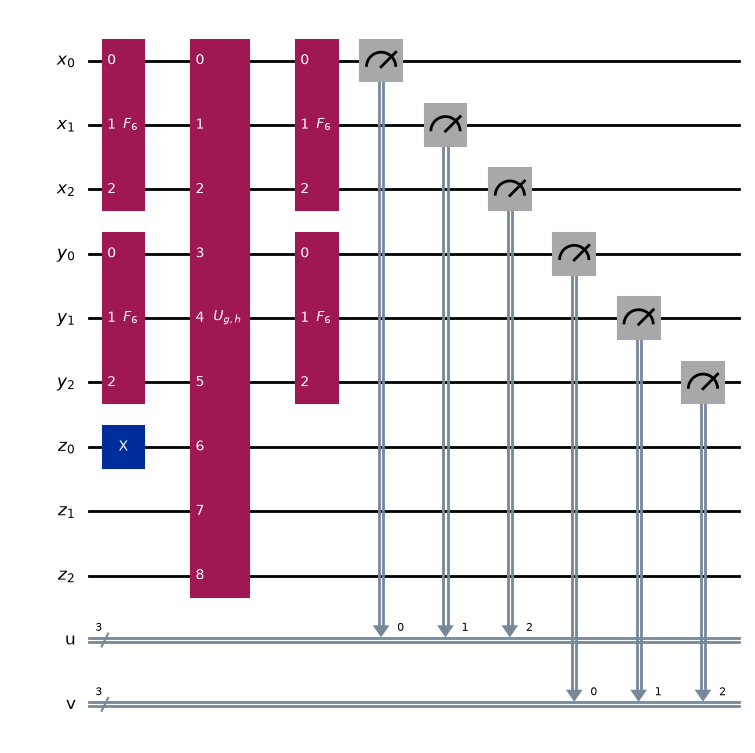

In [6]:
p, g, r, h = 7, 3, 6, 4
oracle = make_dlog_oracle(p, g, h, r)
sampler = StatevectorSampler(seed=np.random.default_rng(2026))

display(dlog_sampling_circuit(oracle, r, p).draw("mpl", fold=-1, style={"fontsize": 10}))

Observed (u, v) pairs: {(0, 0): 1, (1, 2): 9, (2, 4): 3, (3, 0): 7, (4, 2): 7, (5, 4): 3}


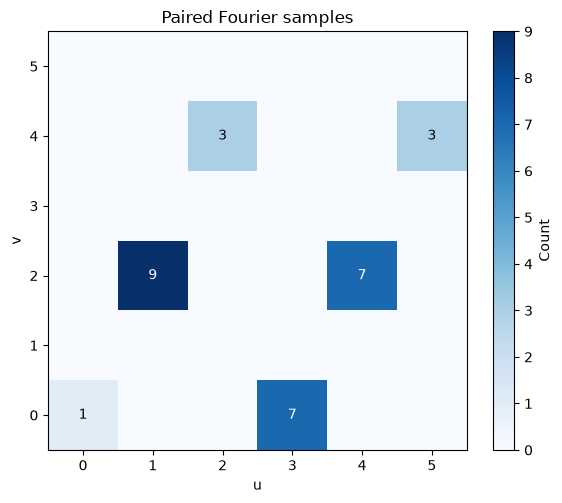

In [7]:
pairs = sample_dlog_pairs(oracle, r, p, shots=30, sampler=sampler)
counts = Counter(pairs)
print("Observed (u, v) pairs:", dict(sorted(counts.items())))

grid = np.zeros((r, r), dtype=int)
for (u, v), count in counts.items():
    grid[v, u] = count
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(grid, origin="lower", cmap="Blues", vmin=0)
ax.set(xticks=range(r), yticks=range(r), xlabel="u", ylabel="v",
       title="Paired Fourier samples")
for (u, v), count in counts.items():
    ax.text(u, v, str(count), ha="center", va="center",
            color="white" if count > grid.max() / 2 else "black")
fig.colorbar(im, ax=ax, label="Count")
fig.tight_layout()
display(fig)
plt.close(fig)

<a id="classical"></a>
## 3. Classical section

### Combine samples when the group order is composite

Each sample satisfies

$$
au_i\equiv-v_i\pmod r.
$$

If $\gcd(u_i,r)=1$, then $a\equiv-v_i u_i^{-1}\pmod r$.
For composite $r$, a nonzero $u_i$ need not have an inverse.
Discarding all such samples would throw away useful information.

Instead, put

$$
d=\gcd(r,u_1,\ldots,u_t).
$$

When $d=1$, the extended Euclidean algorithm gives integers
$c_0,c_1,\ldots,c_t$ such that

$$
c_0r+\sum_{i=1}^t c_i u_i=1.
$$

Multiply by $a$ and substitute the sampled congruences:

$$
a\equiv\sum_{i=1}^t c_i a u_i
\equiv-\sum_{i=1}^t c_i v_i\pmod r.
$$

Thus several samples can recover $a$ even when none of their first
coordinates is individually invertible modulo $r$. For example, the
coefficients $2$ and $3$ together generate $1$ modulo $6$.

### Implement the extended Euclidean update

The code maintains integers $d$ and $b$ satisfying

$$
d=\gcd(r,u_1,\ldots,u_t),
\qquad da\equiv b\pmod r.
$$

Initially, $d=r$ and $b=0$. For a new pair $(u,v)$, compute integers
$\alpha,\beta$ with

$$
d'=\gcd(d,u)=\alpha d+\beta u.
$$

The updated relation follows directly:

$$
d'a\equiv\alpha b-\beta v\pmod r.
$$

Set $b'=(\alpha b-\beta v)\bmod r$. When $d'=1$, the logarithm is $a=b'$.
The reduction of $b'$ modulo $r$ keeps the stored integers small.

For consistent ideal samples, if $d>1$, then $d$ divides $b$ and the
relation determines $a$ only modulo $r/d$. There remain $d$ possible
residues modulo $r$. This implementation waits for more information
instead of searching those candidates.

In [8]:
def extended_gcd(a, b):
    '''Return d, alpha, beta with alpha*a + beta*b = d = gcd(a, b).'''
    if (not isinstance(a, int) or not isinstance(b, int)
            or a < 0 or b < 0):
        raise ValueError("The Euclidean inputs must be nonnegative integers.")
    old_r, remainder = a, b
    old_s, s = 1, 0
    old_t, t = 0, 1
    while remainder:
        quotient = old_r // remainder
        old_r, remainder = remainder, old_r - quotient * remainder
        old_s, s = s, old_s - quotient * s
        old_t, t = t, old_t - quotient * t
    return old_r, old_s, old_t


def update_log_constraint(r, d, b, pairs):
    '''Update d*a = b (mod r) using the measured pair constraints.'''
    exponent_width(r)
    if not isinstance(d, int) or d < 1 or r % d:
        raise ValueError("d must be a positive divisor of r.")
    if not isinstance(b, int) or not 0 <= b < r:
        raise ValueError("b must be an integer in [0, r).")
    for pair in pairs:
        if not isinstance(pair, (tuple, list)) or len(pair) != 2:
            raise ValueError("Each sample must be an (u, v) pair.")
        u, v = pair
        if (not isinstance(u, int) or not isinstance(v, int)
                or not 0 <= u < r or not 0 <= v < r):
            raise ValueError("The sample coordinates must be in [0, r).")
        new_d, alpha, beta = extended_gcd(d, u)
        b = (alpha * b - beta * v) % r
        d = new_d
    return d, b


def logarithm_candidate(r, pairs):
    d, b = update_log_constraint(r, r, 0, pairs)
    return (b if d == 1 else None), d

In [9]:
candidate, divisor = logarithm_candidate(r, pairs)
print("gcd(r, measured u coordinates):", divisor)
print("Candidate logarithm:", candidate)

# Neither u=2 nor u=3 is invertible modulo 6.
d, b = 6, 0
for pair in [(2, 4), (3, 0)]:
    d, b = update_log_constraint(6, d, b, [pair])
    print(f"After {pair}: d={d}, b={b}")
assert d == 1 and b == 4
print("The two noninvertible samples recover a=4.")

gcd(r, measured u coordinates): 1
Candidate logarithm: 4
After (2, 4): d=2, b=2
After (3, 0): d=1, b=4
The two noninvertible samples recover a=4.


### Verify the result and bound the sampling loop

When the combined gcd reaches $1$, verify the candidate with the original
discrete logarithm equation:

$$
g^a\bmod p=h.
$$

Because $g$ has exact order $r$, at most one candidate in
$\{0,\ldots,r-1\}$ passes. A failed check is reported as an error, rather
than returning an unverified answer.

If the gcd is still larger than $1$, collect another batch of quantum
samples. A fixed batch limit prevents an indefinite loop. The state
$(d,b)$ is updated incrementally, so earlier samples need not be stored.

For $h=1$, the unique logarithm in the chosen range is $0$. That case
can be answered directly without quantum sampling.

In [10]:
def recover_discrete_log(
    oracle, p, g, h, r, *, batch_size=6, max_batches=6, seed=2026
):
    '''Recover and verify a in [0, r), without supplying a to the solver.'''
    n, m = check_parameters(p, g, h, r)
    if oracle.num_qubits != 2 * n + m:
        raise ValueError("The oracle size is inconsistent with the parameters.")
    if (not isinstance(batch_size, int) or batch_size < 1
            or not isinstance(max_batches, int) or max_batches < 1):
        raise ValueError("Batch size and maximum batches must be positive.")
    if h == 1:
        return {"logarithm": 0, "sample_count": 0, "batches": 0,
                "verified": True}

    sampler = StatevectorSampler(seed=np.random.default_rng(seed))
    d, b = r, 0
    sample_count = 0
    for batch in range(1, max_batches + 1):
        new_pairs = sample_dlog_pairs(oracle, r, p, batch_size, sampler)
        sample_count += len(new_pairs)
        d, b = update_log_constraint(r, d, b, new_pairs)
        if d == 1:
            if pow(g, b, p) != h:
                raise RuntimeError(
                    "The candidate failed g**a mod p == h. "
                    "Check the oracle, group promises, and sample quality."
                )
            return {"logarithm": b, "sample_count": sample_count,
                    "batches": batch, "verified": True}
    raise RuntimeError(
        f"The combined gcd is {d} after {sample_count} samples. "
        "Increase max_batches for another bounded attempt."
    )

### Run the complete algorithm

This call receives the public instance $(p,g,h,r)$ and its oracle.
The unknown logarithm is not used in the circuit construction or supplied
to the recovery routine.

In [11]:
result = recover_discrete_log(oracle, p, g, h, r)
for key, value in result.items():
    print(f"{key}: {value}")
a = result["logarithm"]
assert pow(g, a, p) == h
print(f"{g}^{a} mod {p} = {h}")

logarithm: 4
sample_count: 6
batches: 1
verified: True
3^4 mod 7 = 4


### Insufficient samples and other group orders

The sample $(0,0)$ supplies no information. For $r=6$, the pair $(2,4)$
alone also leaves the logarithm undetermined, because its first coordinate
shares a factor with $r$.

The remaining examples include the zero logarithm, a prime-order subgroup,
a group whose order is a power of two, and the logarithm $r-1$.

In [12]:
for partial in [[], [(0, 0)], [(2, 4)]]:
    candidate, divisor = logarithm_candidate(6, partial)
    assert candidate is None
    print(f"Samples {partial}: gcd={divisor}, more samples are needed.")

cases = [
    ("Zero logarithm", 7, 3, 6, 1, 0),
    ("Prime-order subgroup", 7, 2, 3, 4, 2),
    ("Power-of-two order", 5, 2, 4, 3, 3),
    ("Logarithm r-1", 7, 3, 6, 5, 5),
]
for label, prime, generator, order, target, expected in cases:
    test_oracle = make_dlog_oracle(prime, generator, target, order)
    recovered = recover_discrete_log(
        test_oracle, prime, generator, target, order, seed=41
    )
    assert recovered["logarithm"] == expected
    print(f"{label}: a={recovered['logarithm']}, shots={recovered['sample_count']}")

Samples []: gcd=6, more samples are needed.
Samples [(0, 0)]: gcd=6, more samples are needed.
Samples [(2, 4)]: gcd=2, more samples are needed.
Zero logarithm: a=0, shots=0
Prime-order subgroup: a=2, shots=6
Power-of-two order: a=3, shots=6


Logarithm r-1: a=5, shots=6


<a id="cost"></a>
## 4. Success probability and computational cost

The first coordinate $u$ of each ideal sample is uniform modulo $r$.
After $t\geq1$ independent shots, insufficient information means

$$
\gcd(r,u_1,\ldots,u_t)>1.
$$

Then some prime divisor $\ell$ of $r$ divides every $u_i$, an event of
probability $\ell^{-t}$. Hence

$$
\Pr(\text{insufficient information})
\leq\sum_{\ell\mid r,\ \ell\ {\rm prime}}\ell^{-t}
\leq\omega(r)2^{-t}
\leq n2^{-t},
$$

where $\omega(r)$ counts distinct prime factors and
$n=\lceil\log_2r\rceil$. Thus
$t\geq\lceil\log_2(n/\delta)\rceil$ suffices for failure probability at most
$\delta$, with $0<\delta<1$. No factorization of $r$ is needed by the recovery
algorithm.

The sampling loop returns a verified logarithm or reports failure.
Its exact-distribution analysis assumes the promised group and ideal
Fourier transforms. It does not model hardware noise.

Let $C_F(r)$ be the gate cost of one Fourier transform on an exponent
register and $C_M(p)$ the cost of one controlled multiplication by a known
residue modulo $p$. The oracle uses at most $2n$ such multiplications.
For $t$ samples, a sufficient quantum gate and measurement bound is

$$
O\!\left(t\left(4C_F(r)+2nC_M(p)+n+m\right)\right),
\qquad m=\lceil\log_2p\rceil.
$$

When $r=2^n$, the exact QFT uses $O(n^2)$ Hadamard and controlled-phase
gates in a model allowing the required rotation angles. The two initial
uniform states then need only $2n$ Hadamard gates.
For other orders, the dense Fourier matrices here use $O(r^2)$ entries.
Each explicit modular-multiplication matrix uses $O(p^2)$ entries.
These matrices make the small circuits executable, but they do not realize
the scalable arithmetic and Fourier constructions needed for Shor's
polynomial-time complexity.

The classical recovery stores only $d$ and $b$ plus the current batch.
Their sizes are $O(n)$ bits. An extended Euclidean computation takes
$O(n)$ iterations on these inputs. Charging a conservative $O(n^2)$
schoolbook bit cost per iteration gives $O(tn^3)$ bit operations for the
updates. A batch of $s$ pairs occupies $O(sn)$ bits. Verifying the final
candidate by repeated squaring takes $O(n)$ modular multiplications on
$m$-bit integers, or a sufficient $O(nm^2)$ schoolbook bit bound.

The controlled multipliers use repeated squaring of public constants.
Their classical construction never solves a discrete logarithm.
However, retaining up to $2n$ dense multiplication matrices can require
$O(np^2)$ complex entries. Statevector simulation separately uses
$O(2^{2n+m})$ complex amplitudes. Keep the demonstrated group sizes small.

## References

- Peter W. Shor,
  [Polynomial-Time Algorithms for Prime Factorization and Discrete Logarithms on a Quantum Computer](https://arxiv.org/abs/quant-ph/9508027).
- Andrew M. Childs and Wim van Dam,
  [Quantum algorithms for algebraic problems](https://arxiv.org/abs/0812.0380),
  Section IV.2 for the known-order discrete logarithm formulation.
- IBM Quantum,
  [QFTGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate),
  [UnitaryGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UnitaryGate),
  and [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler).
- IBM Quantum,
  [Bit ordering](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering).

Return to [Finite Abelian Hidden Subgroups Problems](../README.md).